In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


# Handle Missing Value 



In [3]:
categorical_cols = df.select_dtypes(include=["str"]).columns
numericals_cols = df.select_dtypes(include=["int64"]).columns

In [4]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean") 
df[numericals_cols]= num_imp.fit_transform(df[numericals_cols])

In [5]:
df.head(100)



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1.0,2.0,Graduate,No,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,Approved
1,2.0,0.0,Not Graduate,Yes,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,Rejected
2,3.0,3.0,Graduate,No,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,Rejected
3,4.0,3.0,Graduate,No,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5.0,5.0,Not Graduate,Yes,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96.0,5.0,Graduate,No,300000.0,1100000.0,2.0,300.0,100000.0,500000.0,700000.0,400000.0,Approved
96,97.0,2.0,Graduate,Yes,6600000.0,15000000.0,18.0,470.0,1200000.0,4800000.0,18200000.0,7000000.0,Rejected
97,98.0,2.0,Not Graduate,No,8700000.0,25000000.0,20.0,861.0,14700000.0,8500000.0,23200000.0,7300000.0,Approved
98,99.0,4.0,Graduate,No,9400000.0,29400000.0,12.0,562.0,25900000.0,15200000.0,36400000.0,7100000.0,Approved


In [6]:
cate_imp=SimpleImputer(strategy="most_frequent") 
df[categorical_cols]= cate_imp.fit_transform(df[categorical_cols])

In [8]:
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1.0,2.0,Graduate,No,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,Approved
1,2.0,0.0,Not Graduate,Yes,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,Rejected
2,3.0,3.0,Graduate,No,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,Rejected
3,4.0,3.0,Graduate,No,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5.0,5.0,Not Graduate,Yes,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,Rejected
5,6.0,0.0,Graduate,Yes,4800000.0,13500000.0,10.0,319.0,6800000.0,8300000.0,13700000.0,5100000.0,Rejected
6,7.0,5.0,Graduate,No,8700000.0,33000000.0,4.0,678.0,22500000.0,14800000.0,29200000.0,4300000.0,Approved
7,8.0,2.0,Graduate,Yes,5700000.0,15000000.0,20.0,382.0,13200000.0,5700000.0,11800000.0,6000000.0,Rejected
8,9.0,0.0,Graduate,Yes,800000.0,2200000.0,20.0,782.0,1300000.0,800000.0,2800000.0,600000.0,Approved
9,10.0,5.0,Not Graduate,No,1100000.0,4300000.0,10.0,388.0,3200000.0,1400000.0,3300000.0,1600000.0,Rejected


EDA

<Axes: xlabel=' income_annum', ylabel='Count'>

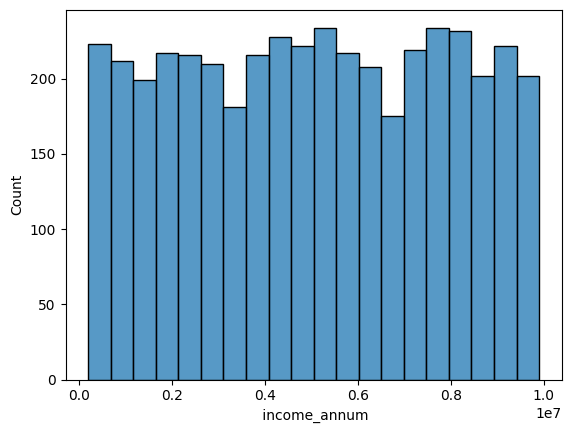

In [21]:
sns.histplot(
    data=df,
    x=" income_annum", 
    bins=20
)
